In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset, random_split
import seaborn as sns
from torch.utils.data import Subset, Dataset

In [51]:
import importlib
import v2_utils
import dataset_utils
import generators
import vae
importlib.reload(v2_utils)
importlib.reload(vae)
importlib.reload(dataset_utils)
from v2_utils import ExperimentRunner, plot_with_anomalies, AdvancedDetectionEvaluator
from vae import VariationalRecurrentAutoencoder, ModelConfig, train_one_epoch, vrae_loss, plot_training_history, train_vrae
from dataset_utils import ChunkedWindowDataset, create_dataloaders, dataset_utils


In [48]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

model = VariationalRecurrentAutoencoder(
    input_dim=50,
    window_size=100,
    hidden_dim=128,
    latent_dim=32,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.1,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

# Синтетические данные для проверки формы тензоров
dummy_data = torch.randn(32, 100, 50).to(device)  # (batch, T, input_dim)

model.train()
reconstructed, z, mu, log_var = model(dummy_data)

loss, recon, kl = vrae_loss(dummy_data, reconstructed, mu, log_var, beta=1.0)
print(f"Total loss: {loss.item():.4f} | Recon: {recon.item():.4f} | KL: {kl.item():.4f}")
print(f"z shape: {z.shape}")        # (32, 32)
print(f"mu shape: {mu.shape}")      # (32, 32)

Total loss: 2.4117 | Recon: 1.0058 | KL: 1.4059
z shape: torch.Size([32, 32])
mu shape: torch.Size([32, 32])


In [50]:
batch_size = 32
epochs = 15
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)
torch.set_grad_enabled(True)

# path = "./windows/new_0.npz"
window_size = 15
latent_dim = window_size * int(np.ceil(np.sqrt(window_size)))
print(latent_dim)
path = f"./windows/windows_chunks_w{window_size}"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size, preload_to_ram=True)

config = ModelConfig(
    input_dim=53,
    window_size=window_size,
    hidden_dim=256,
    # latent_dim=32,
    latent_dim=latent_dim,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.3,
    description="Variational Autoencoder"
)
model = VariationalRecurrentAutoencoder(config=config)


model_saved_path = f"./models/vae_w{window_size}.pth"


train_metrics, test_metrics = train_vrae(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,
    beta=1.0,
    beta_warmup=True,
    warmup_steps=50_000,
    device=device,
    saved_path=model_saved_path,
    patience=10,
    gradient_clip=1.0
)

model.to("cpu")
# torch.save(model.state_dict(), model_saved_path)
plot_training_history(train_metrics, test_metrics)

Device:  cuda:2
60
Preloading all chunks to RAM...
(1000, 15, 53)
Train: 134400, test: 57600
Начинаем обучение VRAE на 15 эпох
Device: cuda:2, Learning rate: 0.001, Beta: 1.0, Beta warmup: True
--------------------------------------------------------------------------------
Epoch   1/15 [53.2s]
  Train - Loss: 0.931264, Recon: 0.855934, KL: 3.479104, Beta: 0.0840
  Test  - Loss: 0.879585, Recon: 0.786669, KL: 1.106417
  ✓ Модель сохранена в ./models/vae_w15.pth (loss: 0.879585)
  Ratio test/train: 0.945
--------------------------------------------------------------------------------
Epoch   2/15 [47.6s]
  Train - Loss: 1.045956, Recon: 0.967499, KL: 0.663625, Beta: 0.1680
  Test  - Loss: 0.946533, Recon: 0.895201, KL: 0.305585
  ✗ No improvement for 1/10 epochs
  Ratio test/train: 0.905
--------------------------------------------------------------------------------
Epoch   3/15 [50.9s]
  Train - Loss: 1.090683, Recon: 1.047412, KL: 0.213663, Beta: 0.2520
  Test  - Loss: 0.992694, Reco

NameError: name 'plt' is not defined

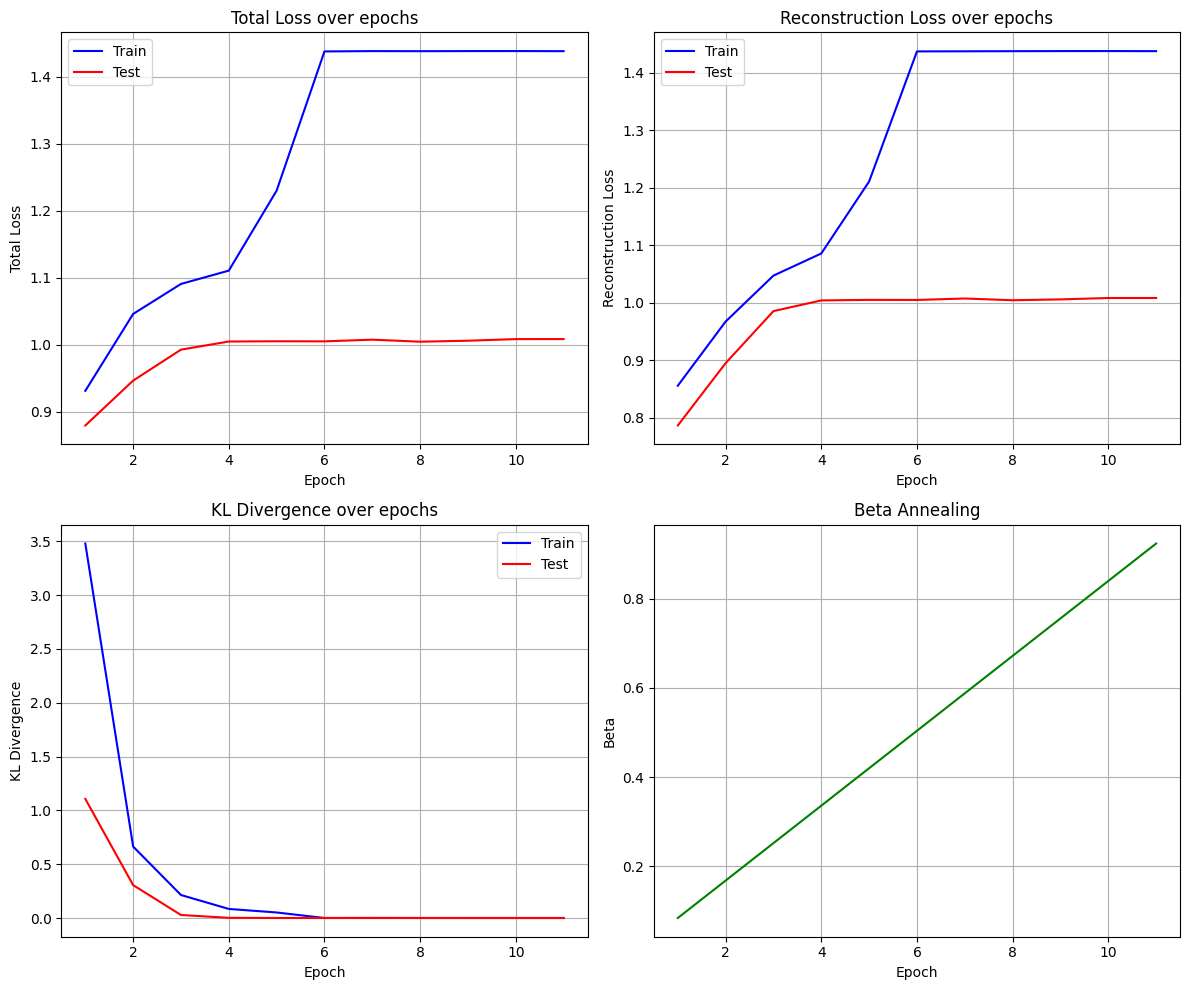

In [52]:
plot_training_history(train_metrics, test_metrics)

Device:  cuda:2
400
Preloading all chunks to RAM...
(1000, 50, 53)
Train: 70000, test: 30000
Начинаем обучение VRAE на 50 эпох
Device: cuda:2, Learning rate: 0.001, Beta: 1.0, Beta warmup: True
--------------------------------------------------------------------------------
Epoch   1/50 [22.4s]
  Train - Loss: 0.907227, Recon: 0.839889, KL: 5.757803, Beta: 0.0437
  Test  - Loss: 2.692988, Recon: 2.585679, KL: 2.453339
  ✓ Модель сохранена в ./models/vae_w50_v2.pth (loss: 2.692988)
  Ratio test/train: 2.968
--------------------------------------------------------------------------------
Epoch   2/50 [22.7s]
  Train - Loss: 0.979945, Recon: 0.842042, KL: 2.111948, Beta: 0.0875
  Test  - Loss: 2.809768, Recon: 2.626086, KL: 2.099231
  ✗ No improvement for 1/10 epochs
  Ratio test/train: 2.867
--------------------------------------------------------------------------------
Epoch   3/50 [24.1s]
  Train - Loss: 1.066281, Recon: 0.844925, KL: 2.024466, Beta: 0.1313
  Test  - Loss: 2.942337, R

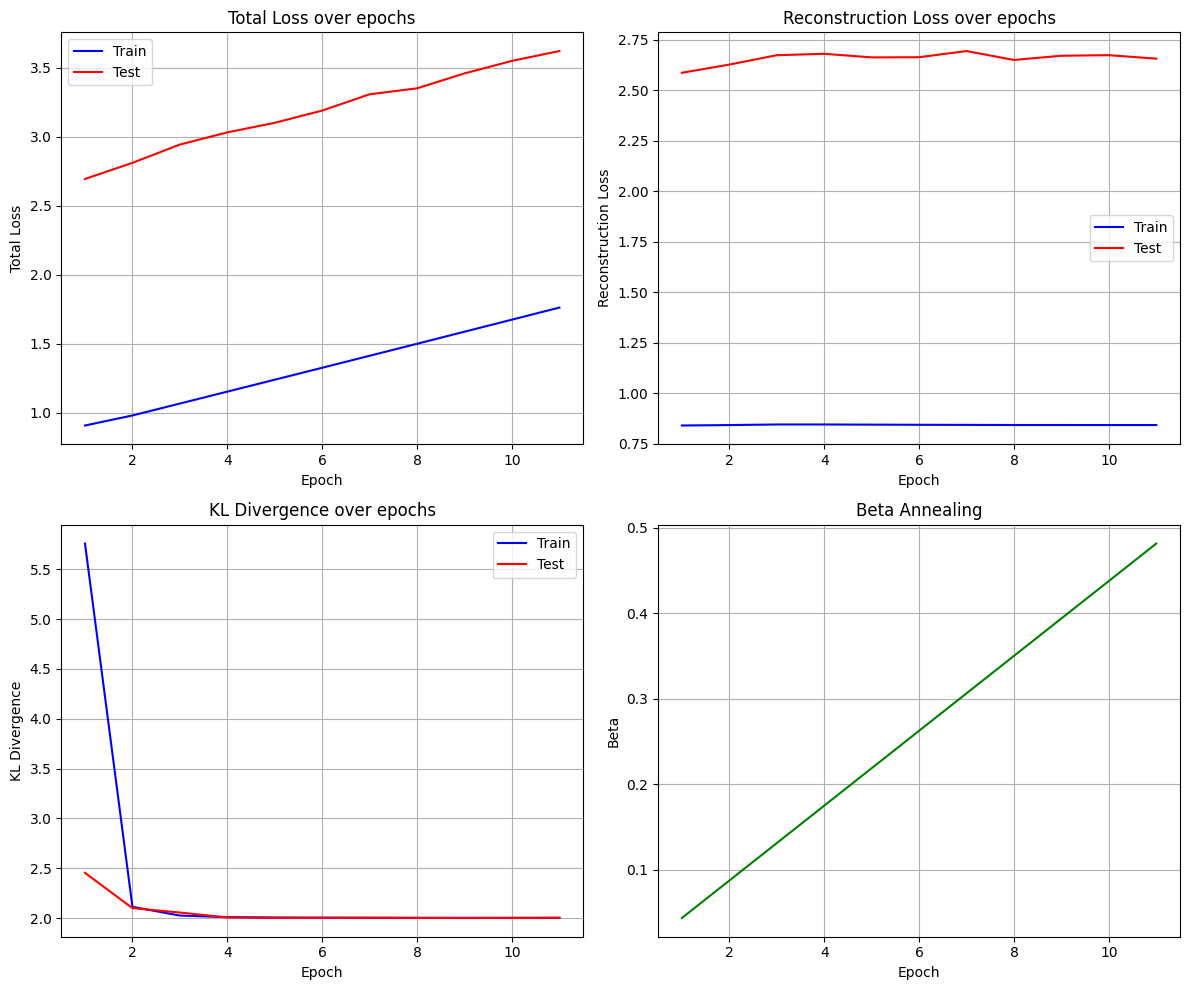

In [55]:
batch_size = 32
epochs = 50
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)
torch.set_grad_enabled(True)

# path = "./windows/new_0.npz"
window_size = 50
latent_dim = window_size * int(np.ceil(np.sqrt(window_size)))
print(latent_dim)
path = f"./windows/windows_chunks_w{window_size}"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size, preload_to_ram=True)

config = ModelConfig(
    input_dim=53,
    window_size=window_size,
    hidden_dim=128,
    # latent_dim=32,
    latent_dim=latent_dim,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.3,
    description="Variational Autoencoder"
)
model = VariationalRecurrentAutoencoder(config=config)


model_saved_path = f"./models/vae_w{window_size}_v2.pth"


train_metrics, test_metrics = train_vrae(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,
    beta=1.0,
    beta_warmup=True,
    warmup_steps=50_000,
    device=device,
    saved_path=model_saved_path,
    patience=10,
    gradient_clip=1.0
)

model.to("cpu")
# torch.save(model.state_dict(), model_saved_path)
plot_training_history(train_metrics, test_metrics)

Device:  cuda:2
400
Preloading all chunks to RAM...
(1000, 50, 53)
Train: 70000, test: 30000
Начинаем обучение VRAE на 50 эпох
Device: cuda:2, Learning rate: 0.001, Beta: 1.0, Beta warmup: True
--------------------------------------------------------------------------------
Epoch   1/50 [45.1s]
  Train - Loss: 0.922155, Recon: 0.852547, KL: 5.899797, Beta: 0.0437
  Test  - Loss: 2.705716, Recon: 2.595284, KL: 2.524726
  ✓ Модель сохранена в ./models/vae_w50.pth (loss: 2.705716)
  Ratio test/train: 2.934
--------------------------------------------------------------------------------
Epoch   2/50 [44.0s]
  Train - Loss: 0.983147, Recon: 0.844850, KL: 2.117796, Beta: 0.0875
  Test  - Loss: 2.827911, Recon: 2.640647, KL: 2.140170
  ✗ No improvement for 1/10 epochs
  Ratio test/train: 2.876
--------------------------------------------------------------------------------
Epoch   3/50 [44.3s]
  Train - Loss: 1.069001, Recon: 0.847152, KL: 2.029189, Beta: 0.1313
  Test  - Loss: 2.960429, Reco

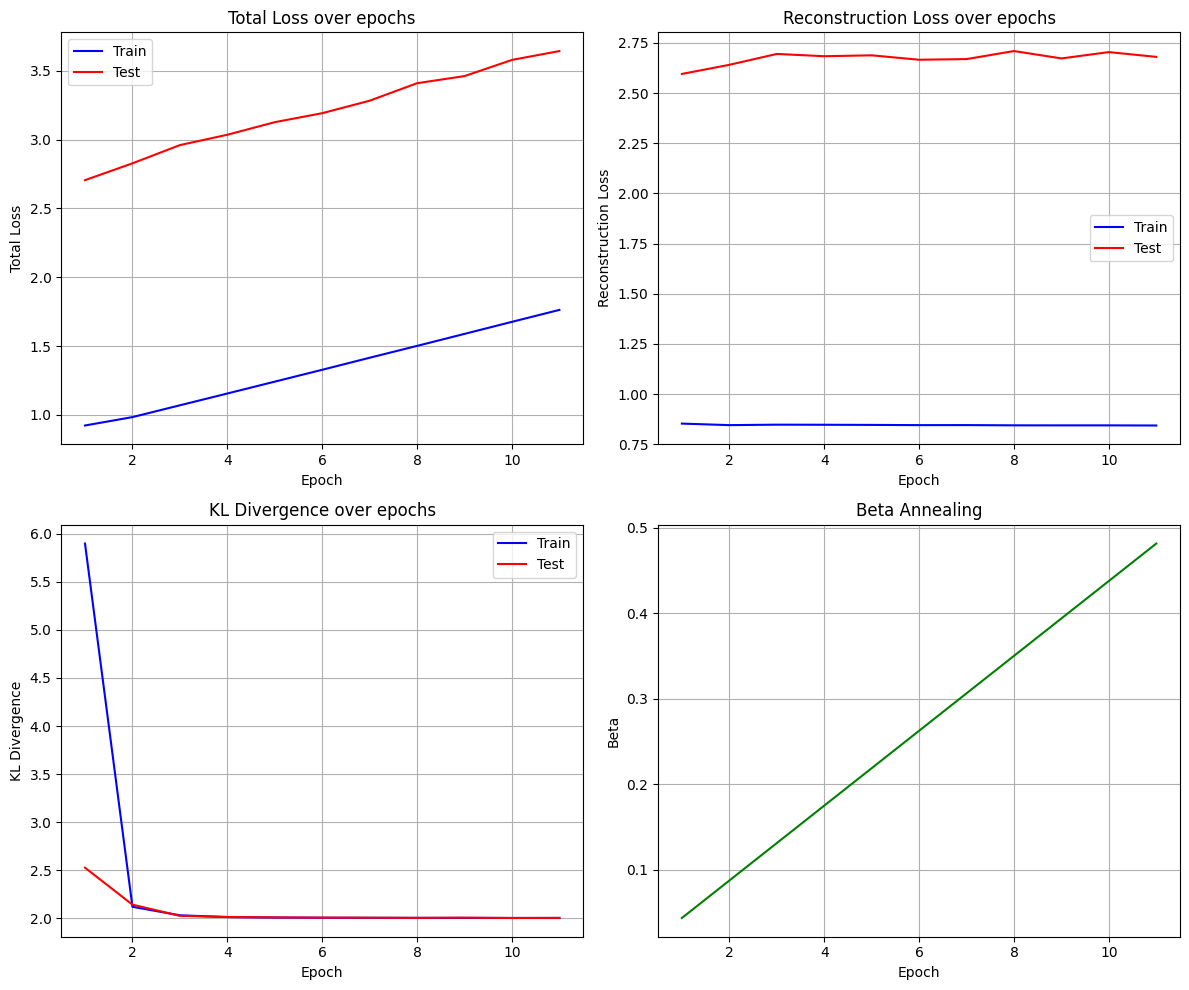

In [54]:
batch_size = 32
epochs = 50
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)
torch.set_grad_enabled(True)

# path = "./windows/new_0.npz"
window_size = 50
latent_dim = window_size * int(np.ceil(np.sqrt(window_size)))
print(latent_dim)
path = f"./windows/windows_chunks_w{window_size}"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size, preload_to_ram=True)

config = ModelConfig(
    input_dim=53,
    window_size=window_size,
    hidden_dim=256,
    # latent_dim=32,
    latent_dim=latent_dim,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.3,
    description="Variational Autoencoder"
)
model = VariationalRecurrentAutoencoder(config=config)


model_saved_path = f"./models/vae_w{window_size}.pth"


train_metrics, test_metrics = train_vrae(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,
    beta=1.0,
    beta_warmup=True,
    warmup_steps=50_000,
    device=device,
    saved_path=model_saved_path,
    patience=10,
    gradient_clip=1.0
)

model.to("cpu")
# torch.save(model.state_dict(), model_saved_path)
plot_training_history(train_metrics, test_metrics)

In [31]:
# Быстрая проверка модели
def test_model_integrity():
    batch_size = 16
    window_size = 15
    input_dim = 53
    hidden_dim = 32
    latent_dim = 32
    
    # model = VariationalRecurrentAutoencoder(
    #     input_dim=input_dim,
    #     window_size=window_size,
    #     hidden_dim=hidden_dim,
    #     latent_dim=latent_dim,
    #     num_layers=1,
    #     rnn_type="GRU",
    #     dropout=0.1
    # )
    model = VariationalRecurrentAutoencoder(config=ModelConfig(
        input_dim=input_dim,
        window_size=window_size,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim,
        num_layers=1,
        rnn_type="GRU",
        dropout=0.1
    ))
    
    x = torch.randn(batch_size, window_size, input_dim)
    reconstructed, z, mu, log_var = model(x)
    
    print(f"Input shape: {x.shape}")
    print(f"Reconstructed shape: {reconstructed.shape}")
    print(f"Latent z shape: {z.shape}")
    print(f"Mu shape: {mu.shape}")
    print(f"Log var shape: {log_var.shape}")
    
    assert reconstructed.shape == x.shape, "Shape mismatch!"
    print("✓ Model integrity check passed")

test_model_integrity()

torch.Size([16, 15, 53])
Input shape: torch.Size([16, 15, 53])
Reconstructed shape: torch.Size([16, 15, 53])
Latent z shape: torch.Size([16, 32])
Mu shape: torch.Size([16, 32])
Log var shape: torch.Size([16, 32])
✓ Model integrity check passed
